In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv('../data/processed/cleaned_telco.csv')
df_model = df[['PaymentMethod','InternetService','TechSupport','Contract','PaperlessBilling','tenure','MonthlyCharges','TotalCharges','Churn']]
df_encoded1 = pd.get_dummies(df_model, drop_first=True)
df_encoded1.columns

Index(['tenure', 'MonthlyCharges', 'TotalCharges',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'InternetService_Fiber optic', 'InternetService_No',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'Churn_Yes'],
      dtype='object')

In [3]:
x = df_encoded1.drop('Churn_Yes', axis=1)
y = df_encoded1['Churn_Yes']

In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [5]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [6]:
y_pred = model.predict(x_test)

In [7]:
y_prob = model.predict_proba(x_test)[:,1]

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy: ", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy:  0.8168914123491838
[[937  99]
 [159 214]]
              precision    recall  f1-score   support

       False       0.85      0.90      0.88      1036
        True       0.68      0.57      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



In [9]:
coefficients = pd.DataFrame({
    'Feature': x.columns, 
    'Coefficients': model.coef_[0]
}).sort_values(by='Coefficients', ascending=False)
print(coefficients)

                                  Feature  Coefficients
6             InternetService_Fiber optic      0.762243
4          PaymentMethod_Electronic check      0.404927
12                   PaperlessBilling_Yes      0.404724
2                            TotalCharges      0.000332
1                          MonthlyCharges     -0.001878
0                                  tenure     -0.057498
3   PaymentMethod_Credit card (automatic)     -0.077231
5              PaymentMethod_Mailed check     -0.078011
9                         TechSupport_Yes     -0.403397
8         TechSupport_No internet service     -0.457877
7                      InternetService_No     -0.457877
10                      Contract_One year     -0.672670
11                      Contract_Two year     -1.475650


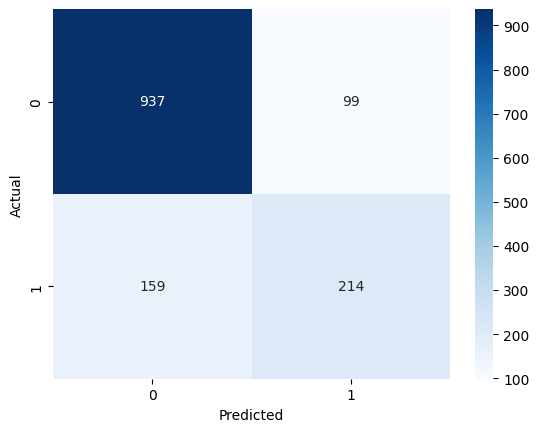

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model Evaluation

The Logistic Regression model achieved an overall accuracy of approximately **82%** on the test dataset, demonstrating reasonable performance in predicting customer churn behavior.

### Classification Performance

- The model achieved a **precision of 0.68** for churned customers, indicating that a significant proportion of predicted churn cases were correctly identified.

- The **recall score of 0.57** for churned customers suggests that the model successfully detected more than half of actual churn cases, while some churn instances remained difficult to capture.

- The model performed particularly well in identifying customers who are unlikely to churn, achieving a **recall of 0.90** for retained customers.

### Confusion Matrix Insights

- **937** non-churn customers were correctly classified.
- **214** churn customers were correctly identified.
- **99** non-churn customers were incorrectly predicted as churn.
- **159** churn customers were missed by the model.

### Conclusion

The Logistic Regression model demonstrates the ability to identify customer churn patterns using customer account information, service usage, and billing characteristics. Features related to contract type, technical support, tenure, and monthly charges appear to contribute significantly to churn prediction.

While the model performs effectively overall, improving recall for churned customers could further enhance its usefulness for proactive customer retention strategies.